Shape of the dataset is (1200, 12). This dataset contains 1200 rows and 12 columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Location                   1060 non-null   object 
 1   Size_sqft                  1094 non-null   float64
 2   Num_Bedrooms               1064 non-null   float64
 3   Num_Bathrooms              1057 non-null   float64
 4   Has_Balcony                1079 non-null   object 
 5   Floor_Number               1068 non-null   float64
 6   Building_Age_Years         1073 non-null   float64
 7   Parking_Available          1099 non-null   object 
 8   Nearby_Schools             1076 non-null   object 
 9   Distance_to_CityCenter_km  1097 non-null   float64
 10  Security_Level             1074 non-null   object 
 11  Price_Category             1200 non-null   object 
dtypes: float64(6), objec

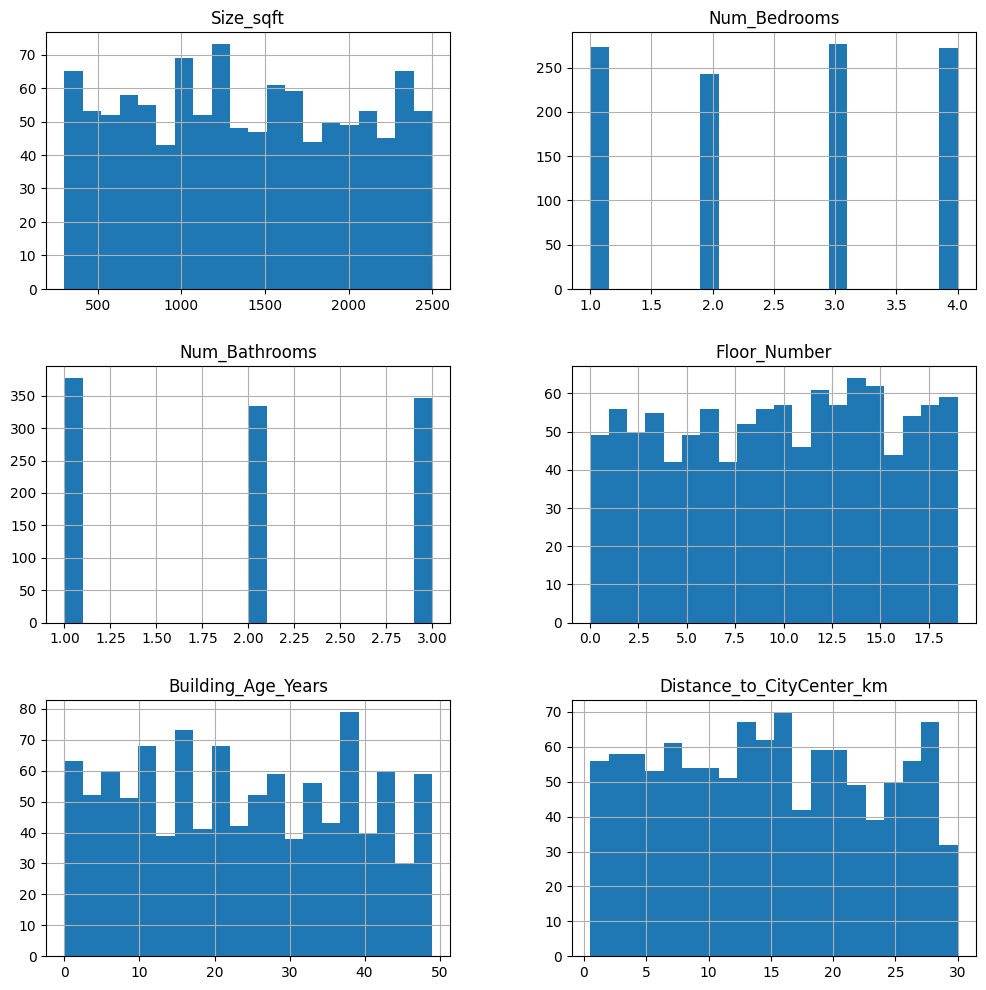

,0
Size_sqft,106
Num_Bedrooms,136
Num_Bathrooms,143
Floor_Number,132
Building_Age_Years,127
Distance_to_CityCenter_km,103


In [1]:
#numerical data analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset=pd.read_csv("/content/flat_price_dataset.csv")
print ('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(dataset.shape,dataset.shape[0],dataset.shape[1]))
dataset.info()

numerical_data = dataset.select_dtypes(include='number')
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

numerical_data.describe().T
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()
numerical_data.isnull().sum()

In [ ]:
#categorical data analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset=pd.read_csv("/content/flat_price_dataset.csv")
print ('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(dataset.shape,dataset.shape[0],dataset.shape[1]))
dataset.info()

categorical_data=dataset.select_dtypes(include= 'object')
categorical_features=categorical_data.columns.tolist()

# Mode (most frequent value) for each categorical column
print("\n⭐ Most Frequent (Mode) Values:")
print(categorical_data.mode().iloc[0])

print(f'There are {len(categorical_features)} categorical_features:', '\n')
print(categorical_features)

categorical_data.describe().T

unique_counts=categorical_data.nunique()
print(unique_counts)
categorical_data.isnull().sum()



Shape of the dataset is (1200, 12). This dataset contains 1200 rows and 12 columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Location                   1060 non-null   object 
 1   Size_sqft                  1094 non-null   float64
 2   Num_Bedrooms               1064 non-null   float64
 3   Num_Bathrooms              1057 non-null   float64
 4   Has_Balcony                1079 non-null   object 
 5   Floor_Number               1068 non-null   float64
 6   Building_Age_Years         1073 non-null   float64
 7   Parking_Available          1099 non-null   object 
 8   Nearby_Schools             1076 non-null   object 
 9   Distance_to_CityCenter_km  1097 non-null   float64
 10  Security_Level             1074 non-null   object 
 11  Price_Category             1200 non-null   object 
dtypes: float64(6), objec

,0
Location,140
Has_Balcony,121
Parking_Available,101
Nearby_Schools,124
Security_Level,126
Price_Category,0


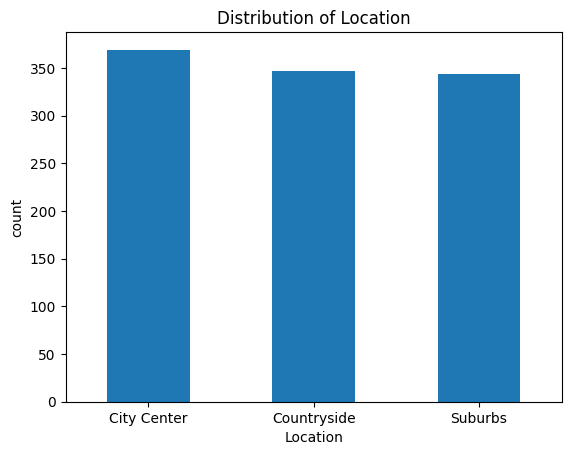

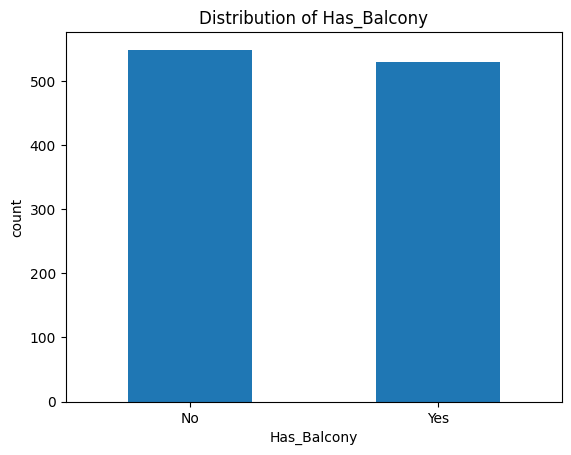

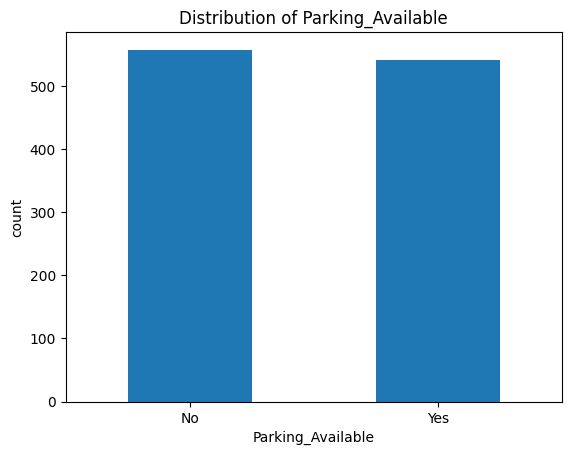

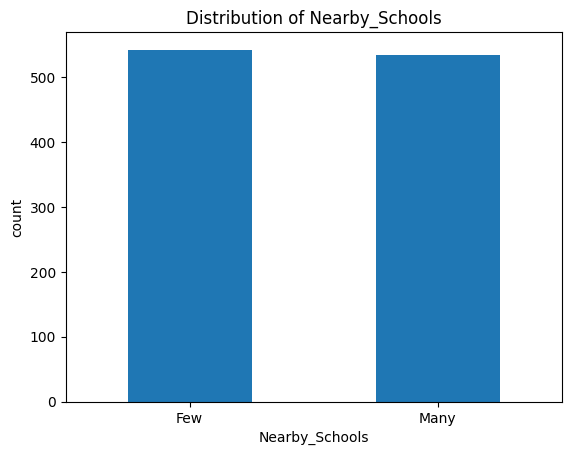

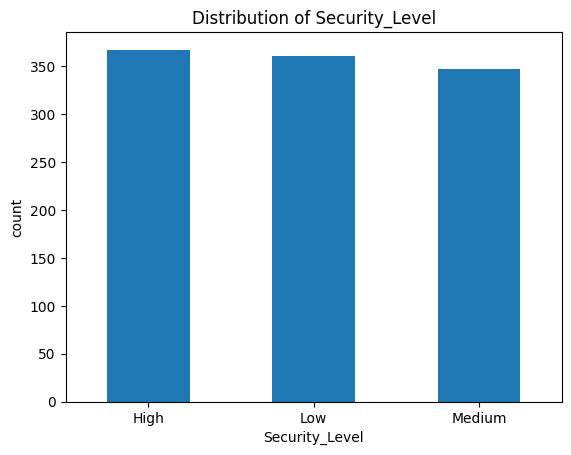

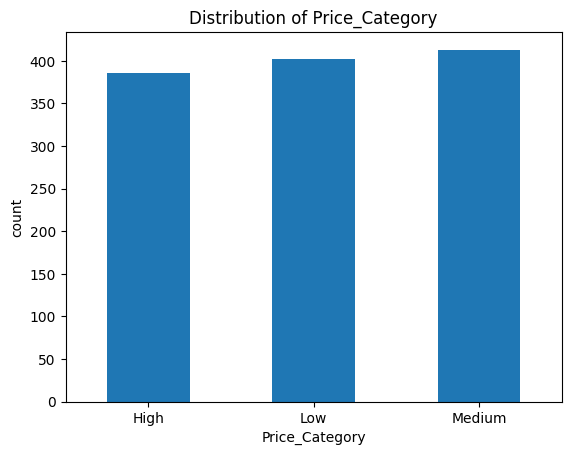

In [ ]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

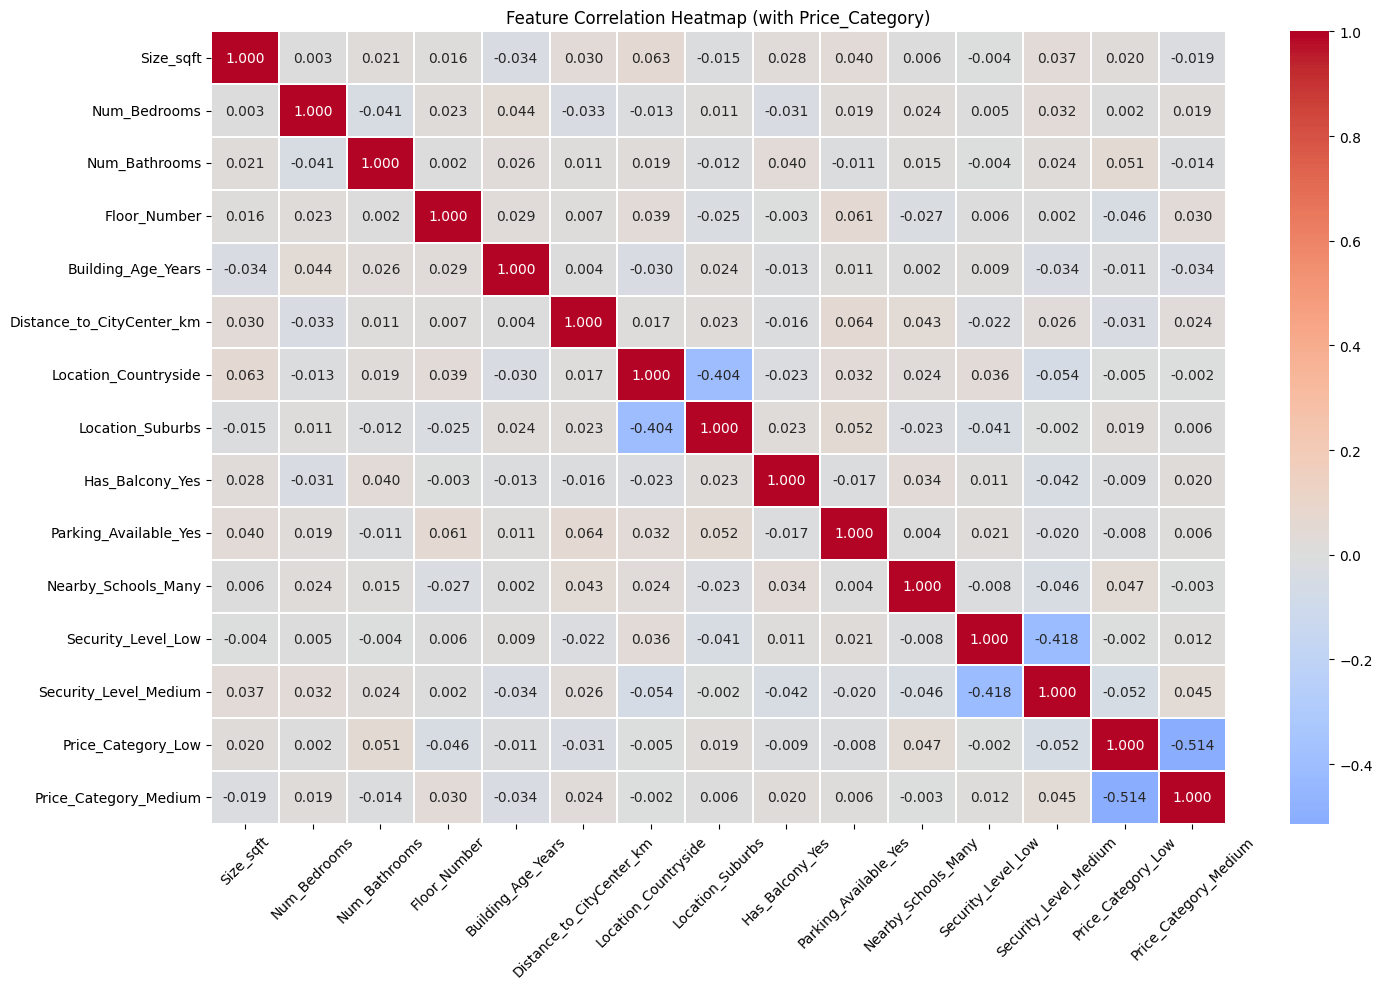

In [ ]:
from sklearn.impute import SimpleImputer

existing_numerical_cols = [col for col in numerical_features if col in dataset.columns]
existing_categorical_cols = [col for col in categorical_features if col in dataset.columns]

# Numerical imputation
if existing_numerical_cols:
    numerical_imputer = SimpleImputer(strategy='median')
    dataset[existing_numerical_cols] = numerical_imputer.fit_transform(dataset[existing_numerical_cols])

# Categorical imputation
if existing_categorical_cols:
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    dataset[existing_categorical_cols] = categorical_imputer.fit_transform(dataset[existing_categorical_cols])

# Encode categorical variables
dataset_encoded = pd.get_dummies(
    dataset,
    columns=existing_categorical_cols,
    drop_first=True
)

# Encode target variable if exists
price_map = {'Low': 0, 'Medium': 1, 'High': 2}
if 'Price_Category' in dataset_encoded.columns:
    dataset_encoded['Price_Category'] = dataset_encoded['Price_Category'].map(price_map)

# Correlation matrix
correlational_matrix = dataset_encoded.corr()

# Plot heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(
    correlational_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".3f",
    linewidths=0.3
)
plt.title("Feature Correlation Heatmap (with Price_Category)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


                Count  Percentage (%)
Price_Category                       
Medium            413           34.42
Low               402           33.50
High              385           32.08


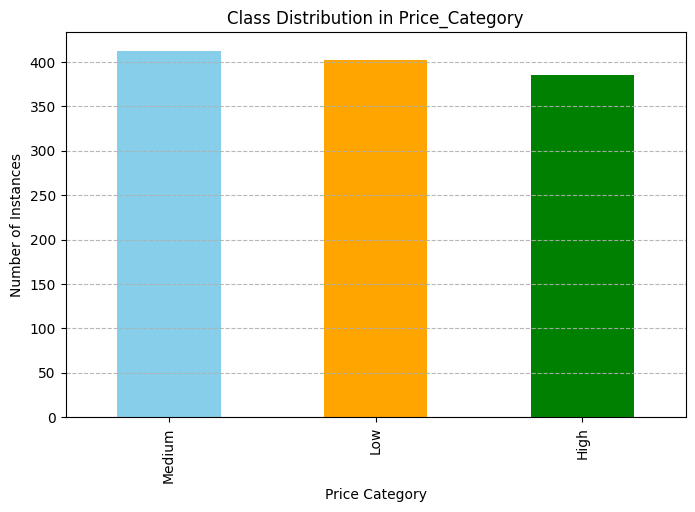

In [ ]:
class_counts = dataset["Price_Category"].value_counts()
class_percentages = dataset["Price_Category"].value_counts(normalize=True) * 100

print(pd.DataFrame({"Count": class_counts, "Percentage (%)": class_percentages.round(2)}))

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar", color=["skyblue", "orange", "green"])
plt.title("Class Distribution in Price_Category")
plt.xlabel("Price Category")
plt.ylabel("Number of Instances")
plt.grid(axis="y", linestyle="--", alpha=0.9)
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier


numerical_cols = ['Size_sqft', 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Number','Building_Age_Years', 'Distance_to_CityCenter_km']
categorical_cols = ['Location', 'Has_Balcony', 'Parking_Available', 'Nearby_Schools', 'Security_Level']

existing_numerical_cols = [col for col in numerical_cols if col in dataset.columns]
existing_categorical_cols = [col for col in categorical_cols if col in dataset.columns]

if existing_numerical_cols:
    numerical_imputer = SimpleImputer(strategy='median')
    dataset[existing_numerical_cols] = numerical_imputer.fit_transform(dataset[existing_numerical_cols])

if existing_categorical_cols:
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    dataset[existing_categorical_cols] = categorical_imputer.fit_transform(dataset[existing_categorical_cols])

# Apply one-hot encoding to categorical columns only
dataset = pd.get_dummies(dataset, columns=existing_categorical_cols, drop_first=True)

# Scaling numerical columns
if existing_numerical_cols:
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(dataset[existing_numerical_cols])
    dataset[existing_numerical_cols] = scaled_features

# Splitting
X = dataset.drop('Price_Category', axis=1)
y = dataset['Price_Category']

# Encoding target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    logreg = LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42)
    logreg.fit(X_train, y_train)
    y_pred = logreg.predict(X_test)
    print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    print(f"KNN Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    #mlp = MLPClassifier(hidden_layer_sizes=(100,50), activation='relu', solver='adam', max_iter=500, random_state=42)
    mlp = MLPClassifier(hidden_layer_sizes=(128,64), activation='relu', solver='adam', max_iter=2000, learning_rate_init=0.001, random_state=42, early_stopping=True)
    mlp.fit(X_train_scaled, y_train)
    y_pred = mlp.predict(X_test_scaled)
    print(f"Neural Network Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

# Random split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.3,
    random_state=42,
)
train_and_evaluate_models(X_train, X_test, y_train, y_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 36.11%
KNN Accuracy: 31.67%
Neural Network Accuracy: 35.00%


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


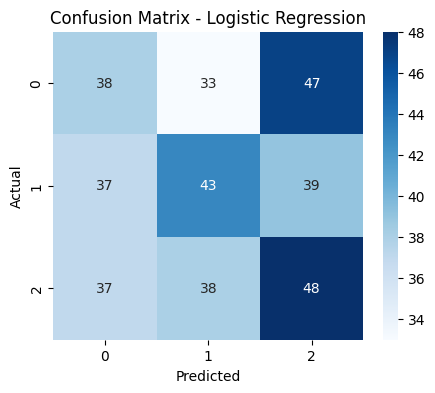

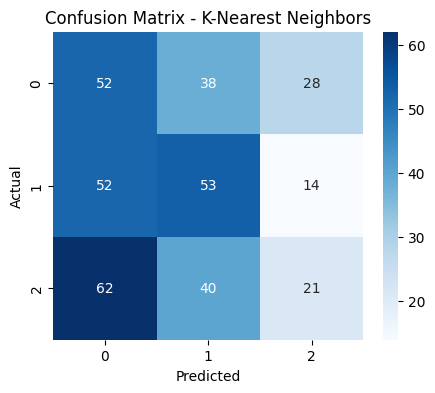

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


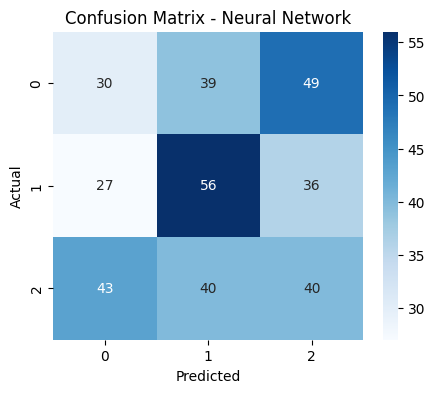

In [ ]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

reports = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    report = classification_report(y_test, y_pred, output_dict=True)
    df = pd.DataFrame(report).T[['precision', 'recall', 'f1-score']]
    reports[name] = df

combined = pd.concat(reports, axis=1)
formatted = combined.swaplevel(axis=1).sort_index(axis=1)
with pd.option_context('display.max_rows', None, 'display.precision', 2):
    print(formatted)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


                        f1-score                                     \
             K-Nearest Neighbors Logistic Regression Neural Network   
0                           0.37                0.33           0.28   
1                           0.42                0.37           0.44   
2                           0.23                0.37           0.32   
accuracy                    0.35                0.36           0.35   
macro avg                   0.34                0.36           0.35   
weighted avg                0.34                0.36           0.35   

                       precision                                     \
             K-Nearest Neighbors Logistic Regression Neural Network   
0                           0.31                0.34           0.30   
1                           0.40                0.38           0.41   
2                           0.33                0.36           0.32   
accuracy                    0.35                0.36           0.35   
macro

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
